In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pickle
import arviz as az
import arviz_plots as azp
from matplotlib.lines import Line2D


In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age',
       'genetic_risk_score_asthma',"lrti_1y"]],df.asthma_0_7yrs

In [3]:
def rescale_splits(idata, folds, X_ref, chains_per_fold=4, per_sd=True):
    W, B = idata["posterior"]["weight"], idata["posterior"]["bias"]
    fdim = W.dims[-1]

    mu_ref = xr.DataArray(np.nanmean(X_ref.values, axis=0), dims=[fdim])
    sd_ref = xr.DataArray(np.nanstd(X_ref.values,  axis=0), dims=[fdim])

    W_out, B_out = xr.full_like(W, np.nan), xr.full_like(B, np.nan)
    for i in range(len(folds["mean_scale"])):
        sl = slice(i * chains_per_fold, (i + 1) * chains_per_fold)
        mu = xr.DataArray(np.asarray(folds["mean_scale"][i]), dims=[fdim])
        sd = xr.DataArray(np.asarray(folds["std_scale"][i]),  dims=[fdim])

        w_nat = W.isel(chain=sl) / sd                              # natural units
        b_nat = B.isel(chain=sl) - ((W.isel(chain=sl) * mu) / sd).sum(dim=fdim)

        if per_sd:
            W_out[dict(chain=sl)] = (w_nat * sd_ref).values
            B_out[dict(chain=sl)] = (b_nat + (w_nat * mu_ref).sum(dim=fdim)).values
        else:
            W_out[dict(chain=sl)] = w_nat.values
            B_out[dict(chain=sl)] = b_nat.values

    assert not np.isnan(W_out).any()
    return np.exp(W_out), B_out

In [4]:


paths = [f"../Models/asthma_7_year_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_7 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_7y.pkl", "rb") as f:
    data_7 = pickle.load(f) 

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","PRS","LRTI"]
combined_posterior_7 = combined_posterior_7.assign_coords(weight_dim_0=list_parameters)
asthma_7 = xr.DataTree.from_dict({"posterior": combined_posterior_7})
asthma_7["posterior"]["weight_OR"],asthma_7["posterior"]["rescaled_bias"]=rescale_splits(asthma_7,data_7,X)


In [5]:


paths = [f"../Models/asthma_12_year_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_12 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_12y.pkl", "rb") as f:
    data_12 = pickle.load(f) 

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","PRS"]
combined_posterior_12 = combined_posterior_12.assign_coords(weight_dim_0=list_parameters)

asthma_12 = xr.DataTree.from_dict({"posterior": combined_posterior_12})
asthma_12["posterior"]["weight_OR"],asthma_12["posterior"]["rescaled_bias"]=rescale_splits(asthma_12,data_12,X)


In [6]:


paths = [f"../Models/asthma_18_year_repeat{j}_fold{i}.nc" for i in range(5) for j in range(5)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_18 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
with open("results_18y.pkl", "rb") as f:
    data_18 = pickle.load(f) 

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","PRS"]
combined_posterior_18 = combined_posterior_18.assign_coords(weight_dim_0=list_parameters)
asthma_18 = xr.DataTree.from_dict({"posterior": combined_posterior_18})
asthma_18["posterior"]["weight_OR"],asthma_18["posterior"]["rescaled_bias"]=rescale_splits(asthma_18,data_18,X)



/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


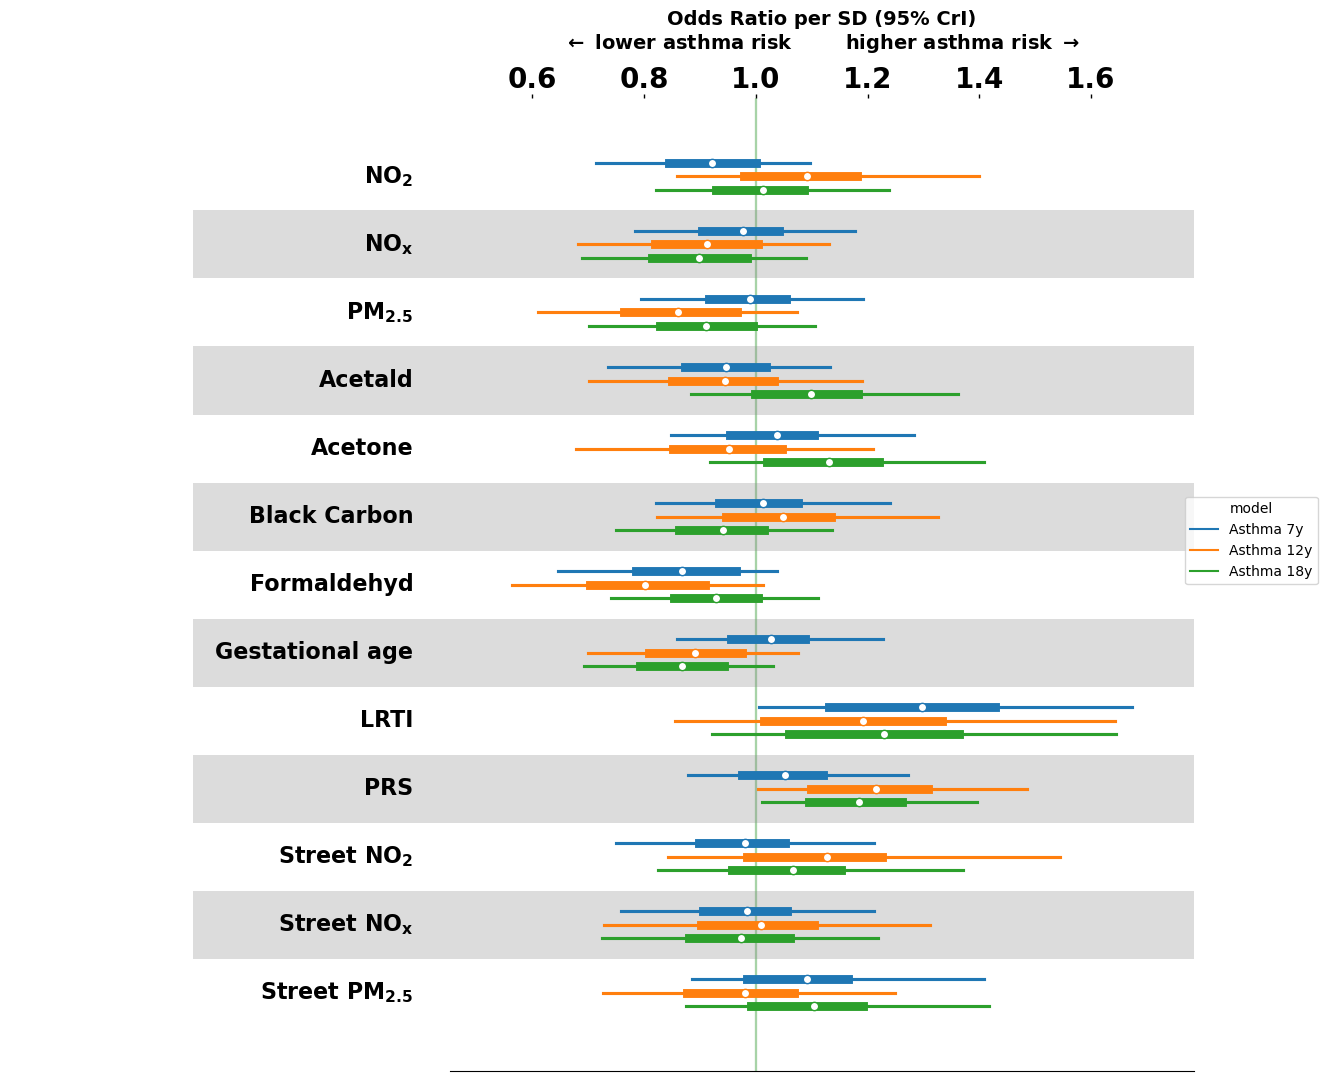

In [7]:

rope = [(0.999, 1.001)]
plt.rcParams["mathtext.default"] = "bf"
plt.rcParams["mathtext.fontset"] = "dejavusans"   # or "custom" + mathtext.bf
pc = azp.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR", shade_label="weight_dim_0",                # native alternate shading
     visuals={"shade": {"color": "0.55"},
             "labels": {"size": 16, "weight": "bold"}}     # gray; alpha 0/0.3 alternates
)
pc.add_legend("model",loc=5)
forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

pc.coords = {"column": "forest"}
pc = azp.add_bands(
    pc,
    values=rope,
    visuals={"ref_band":{"color": "green"}},
)
for spine in ("top", "right", "left"):
    forest_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", labelsize=100, length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=20, pad=0)
forest_ax.set_ylabel("",fontweight="bold",fontsize=40)
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
for ax in fig.axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)
for line in forest_ax.lines:
    c = line.get_color()
    if c not in ("black", "k", "#000000", (0.0, 0.0, 0.0, 1.0)):
        line.set_linewidth(line.get_linewidth() * 3.2)

labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=60, length=0, pad=0)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")
for tl in forest_ax.get_yticklabels():
    tl.set_fontweight("bold")            
for txt in list(fig.texts):
    if "weight" in txt.get_text().lower():
        txt.set_vis
fig.canvas.draw()   # make sure tick labels exist before styling them

for tl in labels_ax.get_yticklabels():
    tl.set_fontweight("bold")

# arviz-plots sometimes draws row labels as Text artists rather than ticks
for txt in labels_ax.texts:
    txt.set_fontweight("bold")
fig.set_layout_engine("none")   # arviz-plots may use constrained layout

extra = 0.15               # figure fraction to steal
lb, fb = labels_ax.get_position(), forest_ax.get_position()
labels_ax.set_position([lb.x0 - extra, lb.y0, lb.width + extra, lb.height])
forest_ax.set_position([fb.x0, fb.y0, fb.width, fb.height])   # unchanged
fig.savefig("../Plots/arviz.png",bbox_inches="tight",dpi=300)

/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


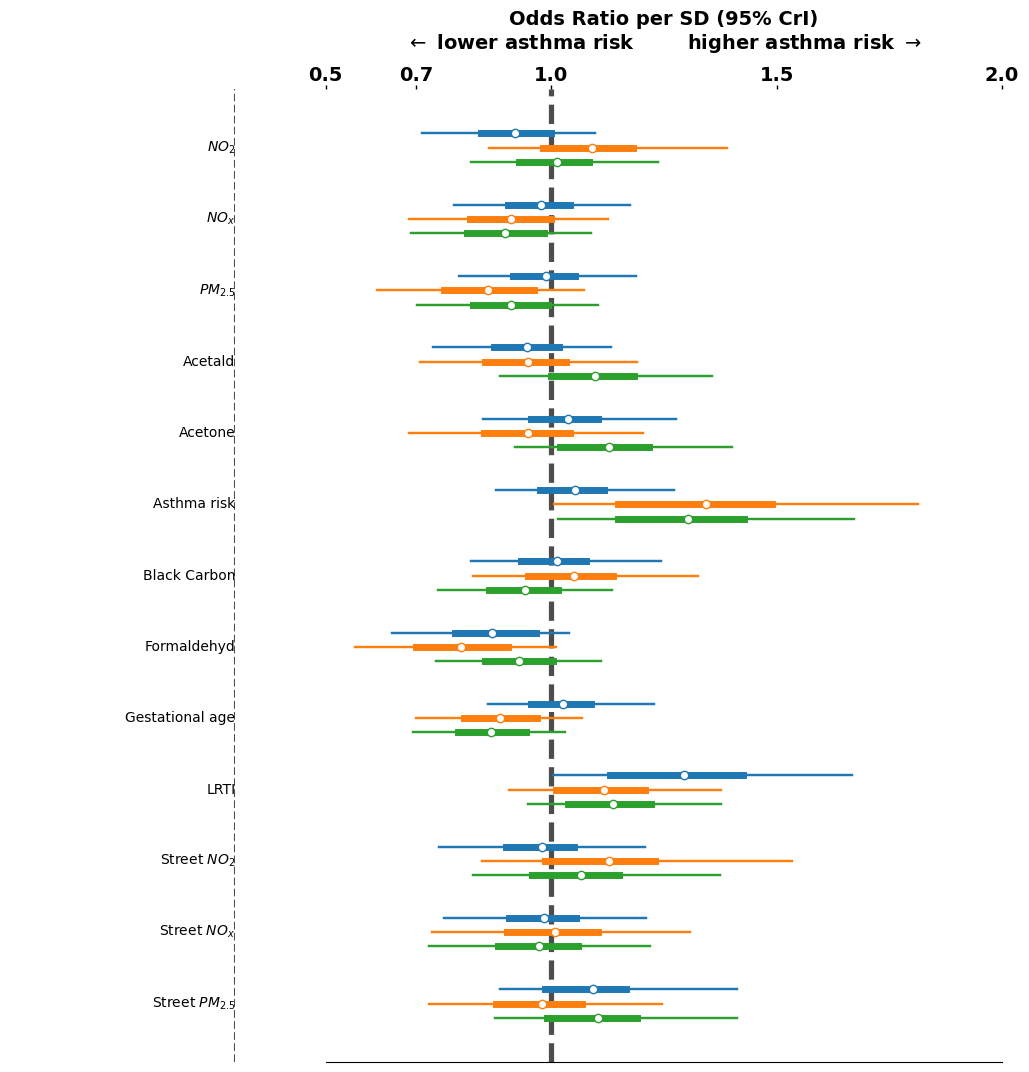

In [9]:


# ============================================================
# Helper: features whose 95% CrI excludes OR = 1
# ============================================================
def excludes_one(idata, var_name="weight_OR", prob=0.95):
    s = az.summary(idata, var_names=[var_name], hdi_prob=prob)
    hdi_cols = sorted([c for c in s.columns if c.startswith("hdi_")])
    lo, hi = hdi_cols[0], hdi_cols[-1]
    mask = (s[lo] > 1) | (s[hi] < 1)
    return {idx.split("[")[-1].rstrip("]") for idx in s.index[mask]}



# ============================================================
# Forest plot — alternate row shading via shade_label
# ============================================================
pc = azp.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR",                 # native alternate shading
    visuals={"shade": {"color": "0.55"}},       # gray; alpha 0/0.3 alternates
)

# Reference line at OR = 1
pc = azp.add_lines(
    pc,
    values=[1.0],
    visuals={"ref_line": {"color": "0.3", "linestyle": "--", "linewidth": 1.5}},
)

forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

# --- Thicken CI lines ---
for line in forest_ax.lines:
    c = line.get_color()
    if c not in ("black", "k", "#000000", (0.0, 0.0, 0.0, 1.0)):
        line.set_linewidth(line.get_linewidth() * 2.5)

# --- Log x-scale ---

forest_ax.set_xlim(0.5, 2.0)
forest_ax.set_xticks([0.5, 0.7, 1.0, 1.5, 2.0])
forest_ax.set_xticklabels(["0.5", "0.7", "1.0", "1.5", "2.0"])

# --- Clean labels (left) axis ---
labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=16, length=0, pad=15)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)

# Bold consistent features; mute the rest
for tl in labels_ax.get_yticklabels():
    tl.set_horizontalalignment("right")
    if tl.get_text() in consistent:
        tl.set_fontweight("bold")
        tl.set_color("black")
    else:
        tl.set_fontweight("normal")
        tl.set_color("0.30")

# --- Clean forest axis ---
for spine in ("top", "right", "left"):
    forest_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", labelsize=64, length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=14, pad=0)
forest_ax.set_ylabel("")
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")
for tl in forest_ax.get_yticklabels():
    tl.set_fontweight("bold")
# --- Hide arviz_plots default debris ---
for ax in fig.axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)
for txt in list(fig.texts):
    if "weight" in txt.get_text().lower():
        txt.set_vis

fig.savefig("../Plots/arviz.png",bbox_inches="tight")

In [10]:
asthma_7

<xarray.DataTree>
Group: /
└── Group: /posterior
        Dimensions:           (chain: 100, draw: 1000, weight_dim_0: 13,
                               weight_raw_dim_0: 13)
        Coordinates:
          * chain             (chain) int64 800B 0 1 2 3 0 1 2 3 0 ... 3 0 1 2 3 0 1 2 3
          * draw              (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
          * weight_dim_0      (weight_dim_0) <U17 884B '$NO_x$' '$NO_2$' ... 'LRTI'
          * weight_raw_dim_0  (weight_raw_dim_0) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
        Data variables:
            bias              (chain, draw) float32 400kB -1.379 -1.901 ... -1.658
            tau               (chain, draw) float32 400kB 0.08428 0.1848 ... 0.1753
            weight            (chain, draw, weight_dim_0) float32 5MB 0.01161 ... 0.1704
            weight_raw        (chain, draw, weight_raw_dim_0) float32 5MB 0.1378 ... ...
            weight_OR         (chain, draw, weight_dim_0) float32 5MB 1.012 ... 1.186
        Attributes:
            created_at:                 2026-08-09T15:57:34.288453+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.21.0
            sample_dims:                ['chain', 'draw']

/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


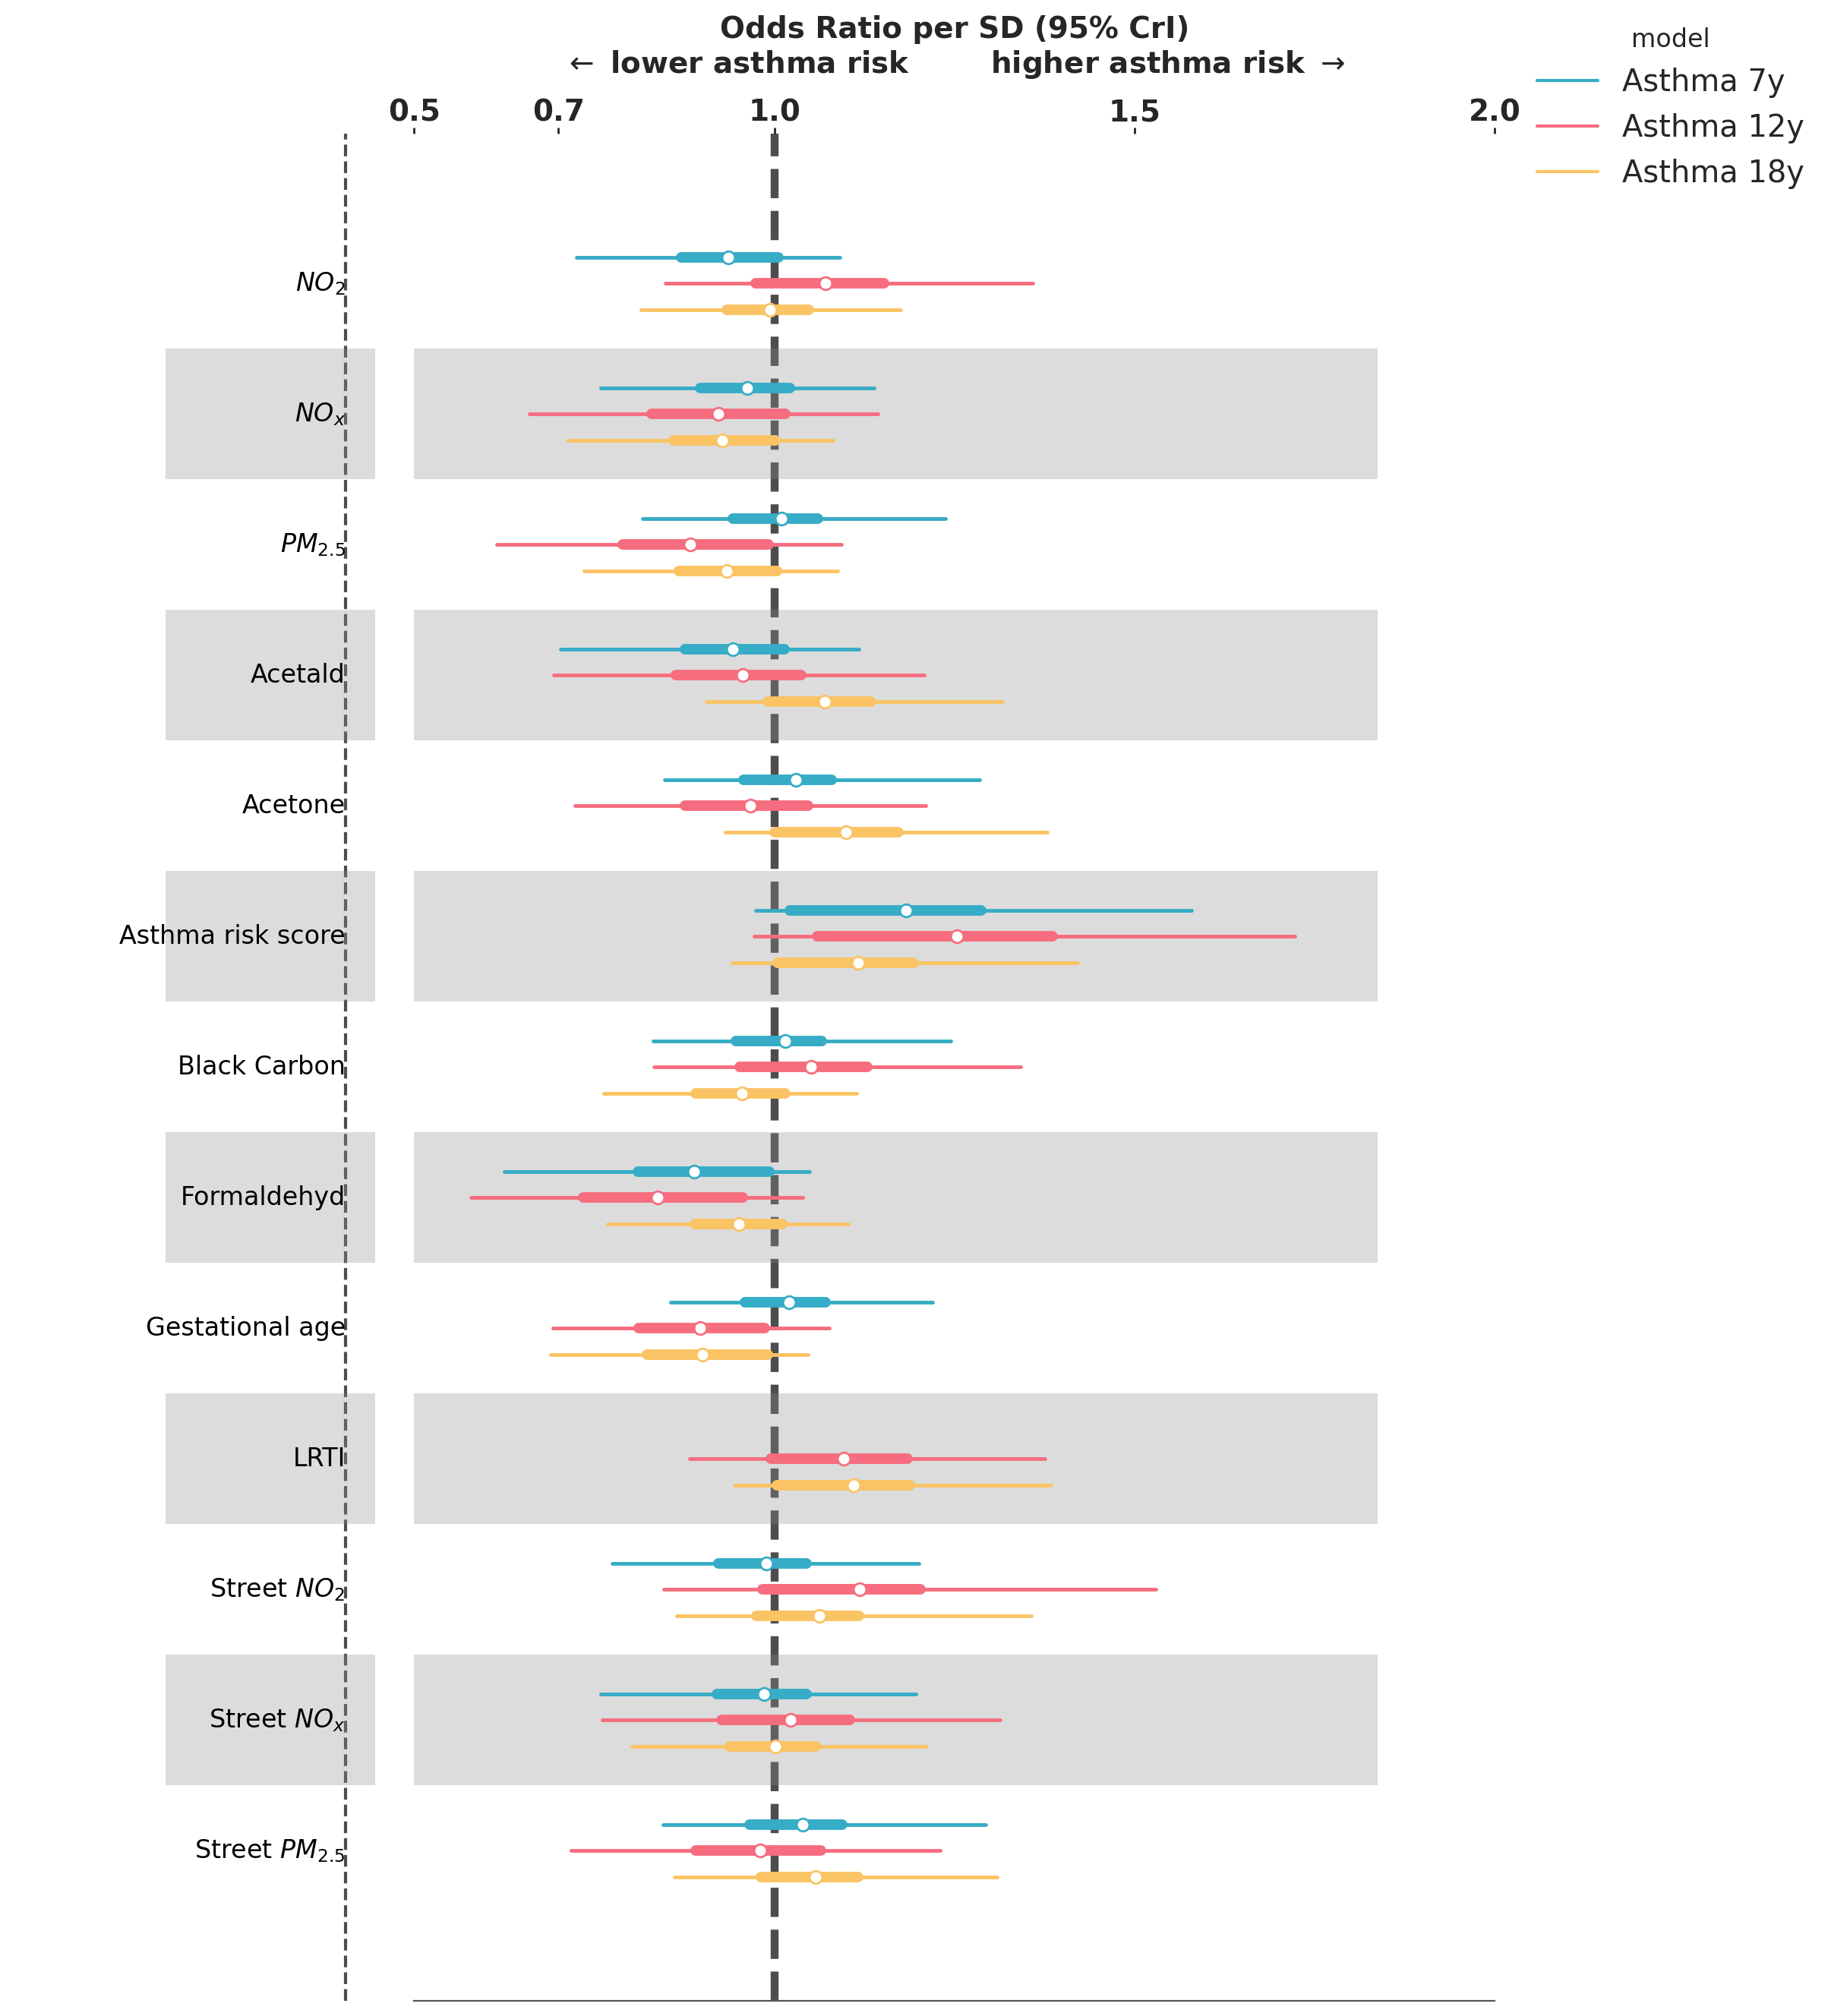

In [21]:


# ============================================================
# Forest plot — alternate row shading via shade_label
# ============================================================
pc = azp.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR", shade_label="weight_dim_0",                # native alternate shading
    visuals={"shade": {"color": "0.55"}},       # gray; alpha 0/0.3 alternates
)

# Reference line at OR = 1
pc = azp.add_lines(
    pc,
    values=[1.0],
    visuals={"ref_line": {"color": "0.3", "linestyle": "--", "linewidth": 1.5}},
)
pc.add_legend("model")
forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

# --- Thicken CI lines ---
for line in forest_ax.lines:
    c = line.get_color()
    if c not in ("black", "k", "#000000", (0.0, 0.0, 0.0, 1.0)):
        line.set_linewidth(line.get_linewidth() * 2.5)

# --- Log x-scale ---
forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

# === PASTE THE 3-LINE BLOCK HERE ===
yticks = labels_ax.get_yticks()
for i in range(0, len(yticks), 2):
    for ax in [labels_ax, forest_ax]:
        ax.axhspan(yticks[i] - 0.5, yticks[i] + 0.5, facecolor="0.9", alpha=0.3, edgecolor="none", zorder=0)
# === END OF BLOCK ===

# --- Thicken CI lines ---
for line in forest_ax.lines:
    ...
forest_ax.set_xlim(0.5, 2.0)
forest_ax.set_xticks([0.5, 0.7, 1.0, 1.5, 2.0])
forest_ax.set_xticklabels(["0.5", "0.7", "1.0", "1.5", "2.0"])

# --- Clean labels (left) axis ---
labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=16, length=0, pad=15)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)

# Bold consistent features; mute the rest
for tl in labels_ax.get_yticklabels():
    tl.set_horizontalalignment("right")
    if tl.get_text() in consistent:
        tl.set_fontweight("bold")
        tl.set_color("black")
    else:
        tl.set_fontweight("normal")
        tl.set_color("0.30")

# --- Clean forest axis ---
for spine in ("top", "right", "left"):
    forest_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", labelsize=64, length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=14, pad=0)
forest_ax.set_ylabel("")
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
# --- Add this block for shading every second row ---
yticks = labels_ax.get_yticks()
for i in range(0, len(yticks), 2):
    for ax in [labels_ax, forest_ax]:
        ax.axhspan(yticks[i] - 0.5, yticks[i] + 0.5, facecolor="0.9", alpha=0.3, edgecolor="none", zorder=0)
# --- End of block ---
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")
for tl in forest_ax.get_yticklabels():
    tl.set_fontweight("bold")
# --- Hide arviz_plots default debris ---
for ax in fig.axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)
for txt in list(fig.texts):
    if "weight" in txt.get_text().lower():
        txt.set_vis
plt.show()
fig.savefig("../Plots/arviz.png",bbox_inches="tight")

In [45]:
print("Y-ticks:", labels_ax.get_yticks())

Y-ticks: []


In [37]:
import arviz as az
import matplotlib.pyplot as plt

# Generate the forest plot
az.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR",
)

# Get the current figure and axes
fig = plt.gcf()
axes = fig.get_axes()

# In ArviZ 1.1, the first axis is the forest plot, and the second is the labels axis
forest_ax = axes[0]
labels_ax = axes[1]

# Get the y positions of the tick labels
yticks = labels_ax.get_yticks()
ylabels = [tl.get_text() for tl in labels_ax.get_yticklabels()]

# Shade every second row using the actual y positions
for i in range(0, len(yticks), 2):
    y_min = yticks[i] - 0.45  # Adjust this value to fit your row height
    y_max = yticks[i] + 0.45
    for ax in [labels_ax, forest_ax]:
        ax.axhspan(y_min, y_max, facecolor="0.9", alpha=0.3, edgecolor="none", zorder=0)

# Bold all y-axis labels
for tl in labels_ax.get_yticklabels():
    tl.set_horizontalalignment("right")
    tl.set_fontweight("bold")
    tl.set_color("black")

# Reference line at OR = 1
for ax in axes:
    ax.axvline(x=1.0, color="0.3", linestyle="--", linewidth=1.5, zorder=1)

# Log x-scale and other customizations
forest_ax.set_xscale("log")
forest_ax.set_xlim(0.5, 2.0)
forest_ax.set_xticks([0.5, 0.7, 1.0, 1.5, 2.0])
forest_ax.set_xticklabels(["0.5", "0.7", "1.0", "1.5", "2.0"])

# Clean up axes
labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=14, length=0, pad=15)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=14, pad=0)
forest_ax.set_ylabel("")
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")

# Hide default text
for ax in axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)

# Save the figure
plt.savefig("../Plots/arviz.png", bbox_inches="tight", dpi=300)
plt.close()

/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


In [38]:
pc